# Graficar rápido V3 — versión simple

Carga una medición (`Datos/medicionNN`), concatena sus chunks, convierte la posición a
**grados** y grafica **x(t)** e **y(t)** con **líneas verticales** en los instantes en que
se colocan las masas.

Después, para cada **tramo** (entre masas) calcula **período** y **equilibrio** sin asumir
ninguna forma para la señal (no hace falta que sea un coseno):

- **Período**: mediana del tiempo entre cruces de un nivel de referencia *en el mismo sentido*.
- **Equilibrio**: mediana de la señal sobre un número **entero** de ciclos.

Las medianas y el conteo de cruces "netos" hacen que ni el ruido ni los glitches de la cámara
muevan el resultado: no hay filtros, ni envolventes, ni ajustes.

In [1]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt

# >>> Elegí la medición a graficar (carpeta dentro de Datos) <<<
CARPETA = os.path.join("..", "Datos", "medicion01")

# ---------- leer metadatos ----------
meta = {}
_metas = glob.glob(os.path.join(CARPETA, "*_meta.txt"))
if _metas:
    with open(_metas[0]) as fh:
        for line in fh:
            line = line.strip()
            if "\t" in line and not line.startswith("#"):
                k, v = line.split("\t", 1)
                meta[k] = v

def _mget(clave, cast=float, default=np.nan):
    try:    return cast(meta[clave])
    except Exception: return default

fecha            = meta.get("fecha", "")
dist_pantalla_cm = _mget("distancia_a_la_pantalla (cm)")

# instantes (s) en que se colocó masa -> líneas verticales
masa_times = sorted(float(v) for k, v in meta.items() if re.match(r"masa_\d+_s$", k))

print("medición:", os.path.basename(CARPETA))
print("  fecha            =", fecha)
print("  dist_pantalla_cm =", dist_pantalla_cm)
print("  masa_times (s)   =", masa_times)

# helper: líneas verticales en los instantes de las masas
def marcar_masas(ax):
    for i, tm in enumerate(masa_times):
        ax.axvline(tm, color="red", ls="--", lw=1.2, alpha=0.8,
                   label=("masa" if i == 0 else None))

medición: medicion01
  fecha            = 2026-06-03T19:19:25
  dist_pantalla_cm = 40.0
  masa_times (s)   = [1000.0, 1894.8]


In [2]:
# Chunks de datos ordenados por su índice nnnn (excluye el _meta) y concatenados
archivos = glob.glob(os.path.join(CARPETA, "*_[0-9][0-9][0-9][0-9].txt"))
archivos.sort(key=lambda f: int(re.search(r"_(\d+)\.txt$", f).group(1)))
print(f"{len(archivos)} archivos encontrados")

datos = []
for f in archivos:
    a = np.atleast_2d(np.loadtxt(f, delimiter="\t"))
    if a.size:                      # ignora chunks vacíos
        datos.append(a)
datos = np.concatenate(datos, axis=0)

t    = datos[:, 0]   # tiempo (s)
x_mm = datos[:, 1]   # posición X (mm)
y_mm = datos[:, 2]   # posición Y (mm)
print("shape:", datos.shape, f"-> {t[-1]:.1f} s de medición")

39 archivos encontrados
shape: (34009, 3) -> 2287.3 s de medición


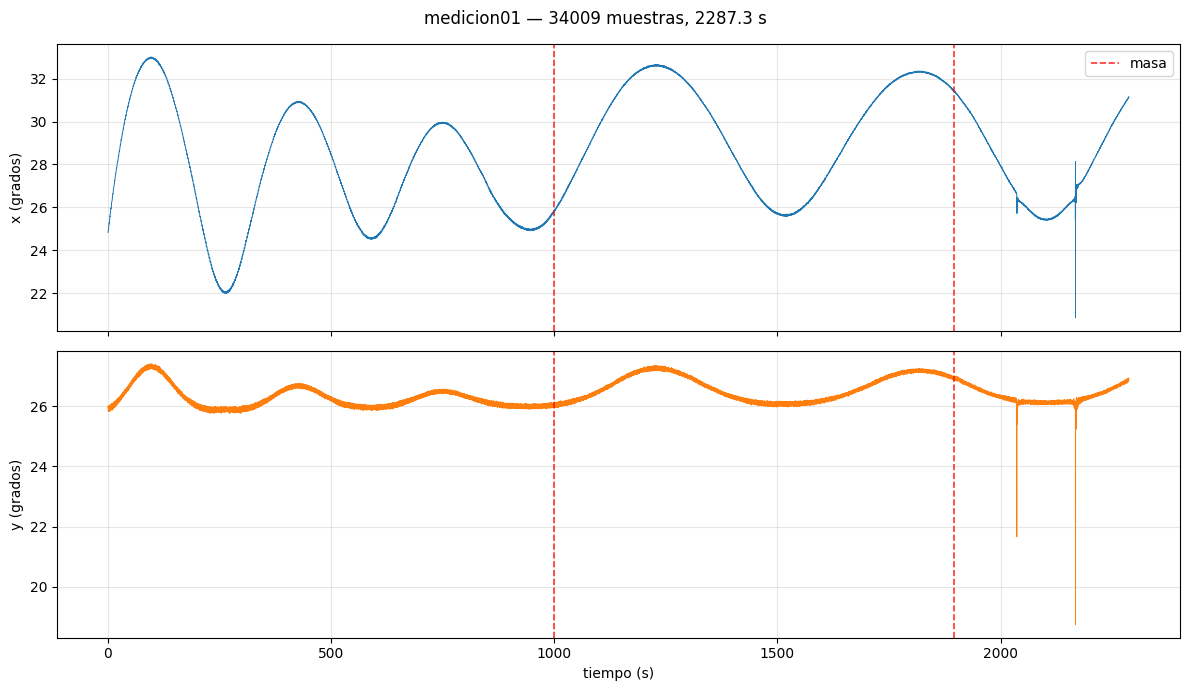

In [3]:
# ---------- mm -> grados (palanca óptica) ----------
# El haz reflejado se desvía 2θ cuando el espejo gira θ -> ángulo del péndulo = haz / 2
FACTOR_ESPEJO = 2.0
if not np.isfinite(dist_pantalla_cm):
    raise ValueError("El meta no tiene 'distancia_a_la_pantalla (cm)'.")
L_mm = dist_pantalla_cm * 10.0   # distancia a la pantalla en mm

def mm_a_grados(v_mm):
    return np.degrees(np.arctan(v_mm / L_mm)) / FACTOR_ESPEJO

x_deg = mm_a_grados(x_mm)
y_deg = mm_a_grados(y_mm)

fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axs[0].plot(t, x_deg, lw=0.7)
axs[0].set_ylabel("x (grados)")
axs[1].plot(t, y_deg, lw=0.7, color="tab:orange")
axs[1].set_ylabel("y (grados)")
axs[1].set_xlabel("tiempo (s)")
for ax in axs:
    ax.grid(alpha=0.3)
    marcar_masas(ax)
if masa_times:
    axs[0].legend(loc="upper right")
fig.suptitle(f"{os.path.basename(CARPETA)} — {len(t)} muestras, {t[-1]:.1f} s")
plt.tight_layout()
plt.show()

## Período y equilibrio por tramo (sin asumir la forma de la señal)

La idea, tramo por tramo:

1. **Nivel de referencia**: la mediana del tramo. No importa que quede corrida del equilibrio
   verdadero: solo se usa para detectar cruces.
2. **Cruces**: instantes donde la señal pasa de un lado al otro del nivel. Si el ruido la hace
   cruzar varias veces seguidas, esos cruces (separados menos de `SEP_MIN_S`) se agrupan en
   uno; y un grupo que termina del mismo lado del que empezó (un glitch que va y vuelve)
   se descarta solo.
3. **Período**: una señal que se repite cruza un nivel fijo *en el mismo sentido* una vez por
   ciclo → `T = mediana de las separaciones entre cruces del mismo sentido`. No depende de
   dónde quedó el nivel ni de la forma de la onda.
4. **Equilibrio**: el promedio/mediana solo es insesgado sobre un número **entero** de ciclos.
   Arrancando en el primer cruce (lo que además saltea el transitorio de apoyar la masa) se
   toma la **mediana de cada ciclo** de duración `T`; el equilibrio del tramo es el promedio
   de esas medianas y su desvío estándar da el error (incluye deriva entre ciclos).

**Ojo:** si un tramo no llega a ~1½ períodos no hay dos cruces del mismo sentido: el período
queda `nan` y el equilibrio se reporta como la mediana simple, **avisando que está sesgada**.
La única solución real para eso es medir más tiempo antes de mover la próxima masa.

In [4]:
# ---------- parámetros ----------
SEP_MIN_S = 60.0   # cruces a menos de esto se agrupan como UN cruce (ruido / glitch).
                   # Regla: mucho menor que medio período, mucho mayor que la duración del ruido.

def segmentos(t, masa_times):
    """Bordes (t_ini, t_fin) de cada tramo entre eventos de masa."""
    cortes = [t[0]] + [m for m in masa_times if t[0] < m < t[-1]] + [t[-1]]
    return list(zip(cortes[:-1], cortes[1:]))

def cruces(t, x, nivel, sep_min_s=SEP_MIN_S):
    """Cruces 'netos' de la señal por `nivel`.
    Agrupa cruces múltiples por ruido (separados < sep_min_s) en uno solo y descarta
    los grupos que terminan del mismo lado del que empezaron (glitches).
    Devuelve (tiempos, direcciones), con dirección +1 si sube y -1 si baja."""
    arriba = x > nivel
    i = np.flatnonzero(arriba[1:] != arriba[:-1])        # índices donde cambia de lado
    if len(i) == 0:
        return np.array([]), np.array([], dtype=int)
    grupos = np.split(np.arange(len(i)), np.flatnonzero(np.diff(t[i]) > sep_min_s) + 1)
    tc, dc = [], []
    for g in grupos:
        antes, despues = arriba[i[g[0]]], arriba[i[g[-1]] + 1]
        if antes == despues:                             # glitch: fue y volvió
            continue
        tc.append(float(t[i[g]].mean()))
        dc.append(+1 if despues else -1)
    return np.array(tc), np.array(dc, dtype=int)

def periodo_por_cruces(t_cr, d_cr):
    """T = mediana de las separaciones entre cruces del MISMO sentido (1 por ciclo).
    Devuelve (T, dispersión, cantidad de separaciones usadas)."""
    seps = np.concatenate([np.diff(t_cr[d_cr > 0]), np.diff(t_cr[d_cr < 0])])
    if len(seps) == 0:
        return np.nan, np.nan, 0
    T_err = float(np.std(seps)) if len(seps) > 1 else np.nan
    return float(np.median(seps)), T_err, len(seps)

def equilibrio_por_ciclos(t, x, t0, T):
    """Mediana de la señal en cada ciclo completo [t0 + j·T, t0 + (j+1)·T].
    Devuelve la lista de medianas (vacía si no entra ni un ciclo completo)."""
    eqs = []
    if np.isfinite(T):
        j = 0
        while t0 + (j + 1) * T <= t[-1]:
            m = (t >= t0 + j * T) & (t < t0 + (j + 1) * T)
            if m.sum() > 10:
                eqs.append(float(np.median(x[m])))
            j += 1
    return eqs

In [5]:
print(f"{'tramo':>5} {'t_ini':>8} {'t_fin':>8} | {'T (s)':>15} {'#sep':>5} | {'equilibrio (deg)':>20}")
tramos = []
for k, (ta, tb) in enumerate(segmentos(t, masa_times)):
    m = (t >= ta) & (t <= tb)
    ts, xs = t[m], x_deg[m]

    nivel = float(np.median(xs))                      # nivel de referencia del tramo
    t_cr, d_cr = cruces(ts, xs, nivel)
    T, T_err, n_sep = periodo_por_cruces(t_cr, d_cr)

    eqs = equilibrio_por_ciclos(ts, xs, t_cr[0], T) if len(t_cr) else []
    if eqs:
        eq      = float(np.mean(eqs))
        eq_err  = float(np.std(eqs)) if len(eqs) > 1 else np.nan
        sesgado = False
    else:                                             # ni un ciclo completo -> mediana simple
        eq, eq_err, sesgado = nivel, np.nan, True

    tramos.append(dict(t_ini=ta, t_fin=tb, nivel=nivel, t_cr=t_cr, d_cr=d_cr,
                       T=T, T_err=T_err, eq=eq, eq_err=eq_err, eqs=eqs, sesgado=sesgado))
    aviso = "   <- tramo corto (<1.5 períodos): eq sesgado" if sesgado else ""
    print(f"{k:>5} {ta:>8.1f} {tb:>8.1f} | {T:>7.1f} ± {T_err:<5.1f} {n_sep:>5} | {eq:>11.4f} ± {eq_err:<6.4f}{aviso}")

# corrimiento del equilibrio entre tramos consecutivos (lo que mide Cavendish)
print()
for k in range(1, len(tramos)):
    a, b = tramos[k - 1], tramos[k]
    d     = b["eq"] - a["eq"]
    derr  = float(np.hypot(a["eq_err"], b["eq_err"]))
    aviso = "   <- ¡no confiable: hay un tramo sesgado!" if (a["sesgado"] or b["sesgado"]) else ""
    print(f"Δequilibrio  tramo {k-1}->{k} = {d:+.4f} ± {derr:.4f} °   (masa en t = {b['t_ini']:.1f} s){aviso}")

tramo    t_ini    t_fin |           T (s)  #sep |     equilibrio (deg)
    0      0.1   1000.0 |   325.0 ± 3.4       4 |     27.7979 ± 0.0892
    1   1000.0   1894.8 |   580.9 ± nan       1 |     29.4512 ± nan   
    2   1894.8   2287.3 |     nan ± nan       0 |     27.8331 ± nan      <- tramo corto (<1.5 períodos): eq sesgado

Δequilibrio  tramo 0->1 = +1.6532 ± nan °   (masa en t = 1000.0 s)
Δequilibrio  tramo 1->2 = -1.6181 ± nan °   (masa en t = 1894.8 s)   <- ¡no confiable: hay un tramo sesgado!


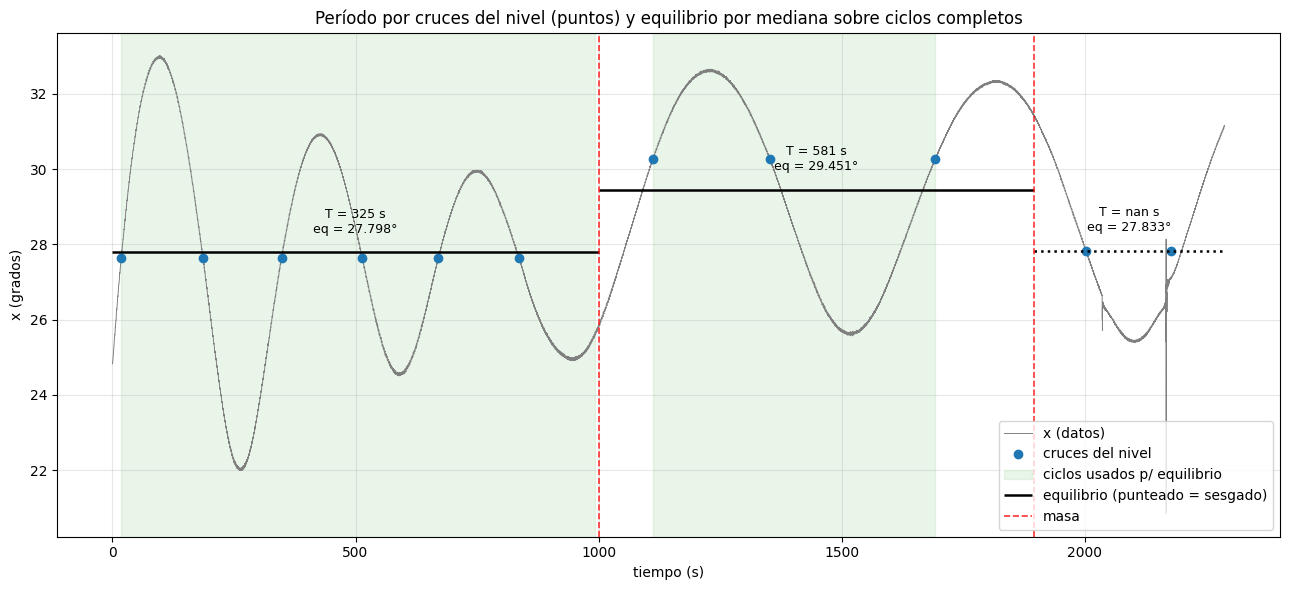

In [6]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(t, x_deg, lw=0.7, color="0.5", label="x (datos)")
for k, tr in enumerate(tramos):
    # cruces usados para medir el período
    if len(tr["t_cr"]):
        ax.plot(tr["t_cr"], np.full(len(tr["t_cr"]), tr["nivel"]), "o", ms=6,
                color="tab:blue", label=("cruces del nivel" if k == 0 else None))
    # ventana de ciclos completos usada para el equilibrio
    if tr["eqs"]:
        t0 = tr["t_cr"][0]
        ax.axvspan(t0, t0 + len(tr["eqs"]) * tr["T"], color="tab:green", alpha=0.10,
                   label=("ciclos usados p/ equilibrio" if k == 0 else None))
    estilo = ":" if tr["sesgado"] else "-"
    ax.hlines(tr["eq"], tr["t_ini"], tr["t_fin"], color="k", ls=estilo, lw=1.8,
              label=("equilibrio (punteado = sesgado)" if k == 0 else None))
    ax.annotate(f"T = {tr['T']:.0f} s\neq = {tr['eq']:.3f}°",
                xy=(0.5 * (tr["t_ini"] + tr["t_fin"]), tr["eq"]),
                xytext=(0, 14), textcoords="offset points", ha="center", fontsize=9)
marcar_masas(ax)
ax.set_xlabel("tiempo (s)")
ax.set_ylabel("x (grados)")
ax.set_title("Período por cruces del nivel (puntos) y equilibrio por mediana sobre ciclos completos")
ax.grid(alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## ---------- máximos y mínimos (como en V2, pero sin filtrar) ----------

 Entre dos cruces netos consecutivos hay exactamente UN punto de giro. En cada intervalo
 (incluyendo los bordes del tramo) se busca el extremo de la MEDIANA local calculada sobre
 una grilla de paso VENTANA_EXTREMO_S: robusto a ruido y glitches, sin filtrar la señal.
 Si el extremo cae en el borde de su intervalo no es un punto de giro y se descarta solo.


tramo 0: 3 máximos, 3 mínimos
   T por extremos = 328.7 ± 13.4 s (4 sep)   [por cruces: 325.0 s]
   amplitud por par (máx−mín)/2 = [5.46 4.43 3.18 2.69 2.5 ]
   midline  por par (máx+mín)/2 = [27.504 26.477 27.732 27.249 27.449]   [eq por ciclos: 27.798]
tramo 1: 2 máximos, 1 mínimos
   T por extremos = 590.9 s (1 sep)   [por cruces: 580.9 s]
   amplitud por par (máx−mín)/2 = [3.5  3.35]
   midline  por par (máx+mín)/2 = [29.128 28.982]   [eq por ciclos: 29.451]
tramo 2: 0 máximos, 1 mínimos


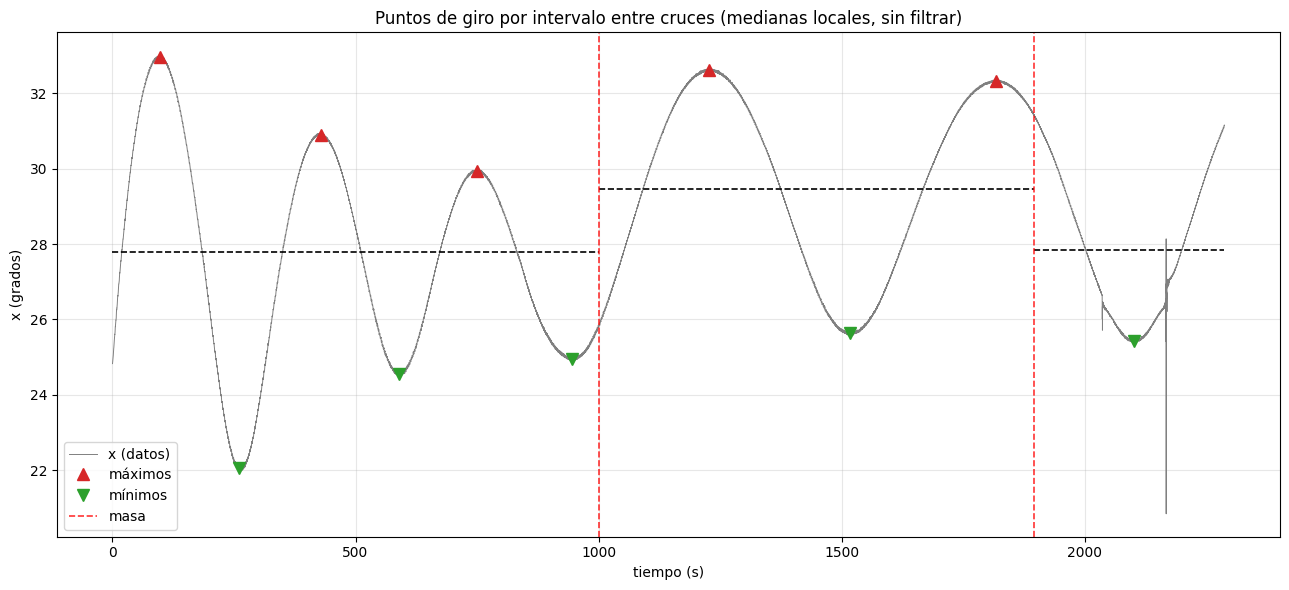

In [ ]:

VENTANA_EXTREMO_S = 5.0   # media ventana de la mediana local (s); agrandar si hay mucho ruido

def extremos_tramo(ts, xs, t_cr, v=VENTANA_EXTREMO_S):
    """Devuelve (t_max, x_max, t_min, x_min) con los puntos de giro del tramo."""
    bordes = np.concatenate([[ts[0]], np.asarray(t_cr, dtype=float), [ts[-1]]])
    tM, xM, tm, xm = [], [], [], []
    for a, b in zip(bordes[:-1], bordes[1:]):
        w = (ts >= a) & (ts <= b)
        if w.sum() < 10:
            continue
        tw, xw = ts[w], xs[w]
        tg = np.arange(a + v, b - v + 1e-9, v)          # grilla gruesa dentro del intervalo
        if len(tg) < 3:
            continue
        med = np.array([np.median(xw[np.abs(tw - g) <= v]) for g in tg])
        for es_max in (True, False):
            j = int(np.argmax(med) if es_max else np.argmin(med))
            if 0 < j < len(tg) - 1:                     # interior -> punto de giro real
                (tM if es_max else tm).append(float(tg[j]))
                (xM if es_max else xm).append(float(med[j]))
    return np.array(tM), np.array(xM), np.array(tm), np.array(xm)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(t, x_deg, lw=0.7, color="0.5", label="x (datos)")
for k, tr in enumerate(tramos):
    m = (t >= tr["t_ini"]) & (t <= tr["t_fin"])
    tM, xM, tm_, xm_ = extremos_tramo(t[m], x_deg[m], tr["t_cr"])
    ax.plot(tM,  xM,  "^", ms=8, color="tab:red",   label=("máximos" if k == 0 else None))
    ax.plot(tm_, xm_, "v", ms=8, color="tab:green", label=("mínimos" if k == 0 else None))
    ax.hlines(tr["eq"], tr["t_ini"], tr["t_fin"], color="k", ls="--", lw=1.2)

    print(f"tramo {k}: {len(tM)} máximos, {len(tm_)} mínimos")
    seps = np.concatenate([np.diff(tM), np.diff(tm_)])
    if len(seps):
        disp = f" ± {np.std(seps):.1f}" if len(seps) > 1 else ""
        print(f"   T por extremos = {np.median(seps):.1f}{disp} s ({len(seps)} sep)"
              f"   [por cruces: {tr['T']:.1f} s]")
    xe = np.concatenate([xM, xm_])
    xe = xe[np.argsort(np.concatenate([tM, tm_]))]      # extremos ordenados en el tiempo
    if len(xe) > 1:
        print(f"   amplitud por par (máx−mín)/2 = {np.round(0.5 * np.abs(np.diff(xe)), 2)}")
        print(f"   midline  por par (máx+mín)/2 = {np.round(0.5 * (xe[1:] + xe[:-1]), 3)}"
              f"   [eq por ciclos: {tr['eq']:.3f}]")
marcar_masas(ax)
ax.set_xlabel("tiempo (s)")
ax.set_ylabel("x (grados)")
ax.set_title("Puntos de giro por intervalo entre cruces (medianas locales, sin filtrar)")
ax.grid(alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()